# MSCS 634 — Final Project (Consolidated)
## Discovering Patterns in Online Shopping Behavior

**Dataset:** Clickstream Data for Online Shopping (UCI ML Repository, ID 553)  
**Team:** Hoai Nam Tran, Mohammed Sajjad Mohammed Arif Ansari  
**Course:** MSCS-634-M20 — Advanced Big Data and Data Mining  
**Instructor:** Dr. Satish Penmatsa, University of the Cumberlands

---

1. **Part 1 — Data Collection, Cleaning, and Exploration** (Deliverable 1)
2. **Part 2 — Regression Modeling and Performance Evaluation** (Deliverable 2)
3. **Part 3 — Classification, Clustering, and Pattern Mining** (Deliverable 3)


---
# Part 1 — Data Collection, Cleaning, and Exploration

## 1. Dataset and Justification

Browsing activity from an online store selling clothing for pregnant women,
April–August 2008: **165,474 click records across 14 attributes**.

We chose it because it supports all four analyses the project requires:
`price` gives a regression target (D2), `main_category` a four-class classification
target (D3), session aggregates the features for clustering (D3) — and each session
is already a basket of clicks, so association rules can be mined without the
artificial discretisation most datasets need.

**Attributes:** `year`, `month`, `day`; `session ID`, `order`; `country` (from IP);
`page 1 (main category)`, `page 2 (clothing model)`, `colour`, `price`; `location`,
`model photography`, `page`; `price 2`.

## 2. Loading and Inspection

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# The file uses semicolon delimiters (European convention), not commas
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")

df = df.rename(columns={
    "order": "click_order", "country": "country_code", "session ID": "session_id",
    "page 1 (main category)": "main_category", "page 2 (clothing model)": "clothing_model",
    "colour": "colour_code", "location": "photo_location",
    "model photography": "model_photography", "price 2": "price_above_avg",
    "page": "page_number",
})

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns\n")
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_null": df.isnull().sum(),
})

Four problems are visible immediately:

1. `year` has one unique value (2008) — zero variance.
2. Most categoricals are stored as integers. `country_code`, `main_category`,
   `colour_code`, `photo_location`, `model_photography`, `price_above_avg` and
   `page_number` are labels encoded as numbers, so pandas treats them as continuous —
   `describe()` would report a mean colour code of about 7, which means nothing.
3. The date is split across three columns.
4. `clothing_model` has 217 levels.


## 3. Data Cleaning

### 3.1 Dropping `year`, recoding categoricals, assembling the date

The recoding matters most: left as integers, these attributes would make regression
models in D2 impose an arbitrary linear ordering on unordered categories, and
distance-based methods in D3 (K-Means, k-NN) compute meaningless distances.
Mappings come from `e-shop clothing 2008 data description.txt`.

`page_number` is deliberately kept numeric, it is genuinely ordinal, since page 3
is deeper into the site than page 2.

In [ ]:
df = df.drop(columns=["year"])   # constant at 2008

maps = {
    "main_category": {1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"},
    "colour_code": {1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy",
                    6: "gray", 7: "green", 8: "navy blue", 9: "many colours",
                    10: "olive", 11: "pink", 12: "red", 13: "violet", 14: "white"},
    "photo_location": {1: "top left", 2: "top middle", 3: "top right",
                       4: "bottom left", 5: "bottom middle", 6: "bottom right"},
    "model_photography": {1: "en face", 2: "profile"},
    "price_above_avg": {1: "yes", 2: "no"},
    "country_code": {
        1: "Australia", 2: "Austria", 3: "Belgium", 4: "British Virgin Islands",
        5: "Cayman Islands", 6: "Christmas Island", 7: "Croatia", 8: "Cyprus",
        9: "Czech Republic", 10: "Denmark", 11: "Estonia", 12: "unidentified",
        13: "Faroe Islands", 14: "Finland", 15: "France", 16: "Germany", 17: "Greece",
        18: "Hungary", 19: "Iceland", 20: "India", 21: "Ireland", 22: "Italy",
        23: "Latvia", 24: "Lithuania", 25: "Luxembourg", 26: "Mexico",
        27: "Netherlands", 28: "Norway", 29: "Poland", 30: "Portugal", 31: "Romania",
        32: "Russia", 33: "San Marino", 34: "Slovakia", 35: "Slovenia", 36: "Spain",
        37: "Sweden", 38: "Switzerland", 39: "Ukraine", 40: "United Arab Emirates",
        41: "United Kingdom", 42: "USA", 43: "biz", 44: "com", 45: "int",
        46: "net", 47: "org"},
}

# Verify every observed code has a mapping before applying
for col, m in maps.items():
    unmapped = set(df[col].unique()) - set(m.keys())
    print(f"{col:<20} unmapped: {sorted(unmapped) if unmapped else 'none'}")

df["colour"] = df["colour_code"].map(maps["colour_code"])
df["country"] = df["country_code"].map(maps["country_code"])
for col in ["main_category", "photo_location", "model_photography", "price_above_avg"]:
    df[col] = df[col].map(maps[col])
df = df.drop(columns=["colour_code"])

# Assemble date - also validates it (month 4 day 31 would give NaT)
df["date"] = pd.to_datetime(dict(year=2008, month=df["month"], day=df["day"]),
                            errors="coerce")
df["weekday"] = df["date"].dt.day_name()
print(f"\nInvalid dates: {df['date'].isna().sum()}   "
      f"Range: {df['date'].min().date()} to {df['date'].max().date()}")

### 3.2 Missing values 

The description file lists 47 country codes, and **code 12 is `unidentified`** — an
IP that could not be resolved. That is a missing value, but stored as a valid
integer inside the normal code range it could not be found by `isnull(). It is findable only by reading the
documentation: **the data dictionary is part of the data.**

In [ ]:
# The documentation is what finds it
n_unid = int((df["country_code"] == 12).sum())
print(f"\nCountry code 12 (unidentified): {n_unid:,} records "
      f"({100 * n_unid / len(df):.3f}%)")

# Treatment: flag the attribute, keep the records
df["country_known"] = df["country_code"] != 12
df.loc[df["country_code"] == 12, "country"] = np.nan

# Duplicates: identical content rows are legitimate (a user can click the same
# product twice). The meaningful check is the session/order key.
print(f"Duplicated (session_id, click_order): "
      f"{df.duplicated(subset=['session_id', 'click_order']).sum()}")

# Country is dominated by one market - group by observed frequency
freq = df["country_code"].value_counts()
major = freq[freq >= 0.005 * len(df)].index.tolist()
df["country_group"] = np.where(
    ~df["country_known"], "unidentified",
    np.where(df["country_code"] == freq.index[0], "domestic",
             np.where(df["country_code"].isin(major), "major_foreign", "other_foreign")))

print(f"\nDominant market: {maps['country_code'][freq.index[0]]} "
      f"({100 * freq.iloc[0] / len(df):.1f}% of clicks)")


Country code 12 (unidentified): 210 records (0.127%)
Duplicated (session_id, click_order): 0

Dominant market: Poland (81.0% of clicks)


**Treatment: retain the records, flag the attribute.** Dropping them would discard
complete, valid observations of category, colour, price and page depth over an
attribute most of the analysis does not use. `country_known` makes the exclusion
explicit wherever country is involved.

### Cleaning summary

- **Semicolon-delimited file** — loaded with `sep=";"`
- **`year` constant at 2008** — dropped (zero variance)
- **Six categoricals stored as integers** — recoded to labels; `page_number` kept ordinal
- **Date split across three columns** — assembled and validated
- **Country code 12 = `unidentified`** — 210 records flagged, `country` set to `NaN`
- **Duplicates** — session/order key verified; content repeats retained as genuine
- **Country imbalance** — grouped by observed frequency

## 4. Unit of Analysis

Each row is one **click**, but our questions are about **sessions**.

That matters because models treat each row as a separate observation. A visitor who
clicks 50 times would count 50 times, while one who clicks twice counts twice, so
heavy browsers would dominate the results.

We therefore collapsed the clicks into one row per session, keeping both versions:
click level for association rules and screen-position analysis, session level for
clustering and session outcomes.

In [ ]:
sessions = df.groupby("session_id").agg(
    n_clicks=("click_order", "count"),
    max_page=("page_number", "max"),
    n_categories=("main_category", "nunique"),
    n_products=("clothing_model", "nunique"),
    n_colours=("colour", "nunique"),
    mean_price=("price", "mean"),
    max_price=("price", "max"),
    min_price=("price", "min"),
    country_group=("country_group", "first"),
    weekday=("weekday", "first"),
    date=("date", "first"),
).reset_index()

sessions["price_range"] = sessions["max_price"] - sessions["min_price"]

sessions["dominant_category"] = sessions["session_id"].map(
    df.groupby(["session_id", "main_category"]).size().reset_index(name="n")
      .sort_values(["session_id", "n"], ascending=[True, False])
      .drop_duplicates("session_id").set_index("session_id")["main_category"])

# Engineered classification target.
# outcome - this dataset records browsing only.
sessions["deep_session"] = np.where(sessions["max_page"] >= 3, "deep", "shallow")

print(f"{len(df):,} clicks -> {len(sessions):,} sessions "
      f"({len(df)/len(sessions):.2f} each)\n")
print((sessions["deep_session"].value_counts(normalize=True) * 100).round(1).to_string())

165,474 clicks -> 24,026 sessions (6.89 each)

deep_session
shallow    62.0
deep       38.0


## 5. Outlier Detection

Assessed at **session** level — a single click cannot meaningfully be an outlier,
but a session of several hundred clicks is a genuine anomaly. Both the IQR rule
(1.5 × IQR) and z-scores are applied, since each has a distinct weakness.

In [ ]:
num_cols = ["n_clicks", "max_page", "n_categories", "n_products",
            "mean_price", "price_range"]

rows = []
for col in num_cols:
    q1, q3 = sessions[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (sessions[col] < q1 - 1.5*iqr) | (sessions[col] > q3 + 1.5*iqr)
    z = ((sessions[col] - sessions[col].mean()) / sessions[col].std()).abs()
    rows.append({"feature": col, "median": sessions[col].median(),
                 "max": sessions[col].max(), "skew": round(sessions[col].skew(), 2),
                 "IQR_outliers": int(mask.sum()), "z>3": int((z > 3).sum())})

sessions["log_n_clicks"] = np.log1p(sessions["n_clicks"])
sessions["is_extreme"] = sessions["n_clicks"] > sessions["n_clicks"].quantile(0.99)
pd.DataFrame(rows)

,feature,median,max,skew,IQR_outliers,z>3
0,n_clicks,4.000000,195.0,4.88,1962,467
1,max_page,2.000000,5.0,0.67,0,0
2,n_categories,2.000000,4.0,0.79,0,0
3,n_products,4.000000,168.0,4.53,1582,473
4,mean_price,43.666667,82.0,0.46,405,139
5,price_range,24.000000,64.0,0.23,0,0


**Decision: retain all sessions.** A long session is not a measurement error, it is
a visitor who browsed extensively, precisely the behaviour of interest. Removing
them would delete the most informative records and bias results toward casual
browsers.

The right skew is a property of the process, not a defect: web session lengths are
characteristically heavy-tailed, and the IQR rule assumes rough symmetry, so here it
flags the distribution's natural shape. Extreme sessions were **flagged** instead,
and a log transform prepared for the scale-sensitive clustering in D3.

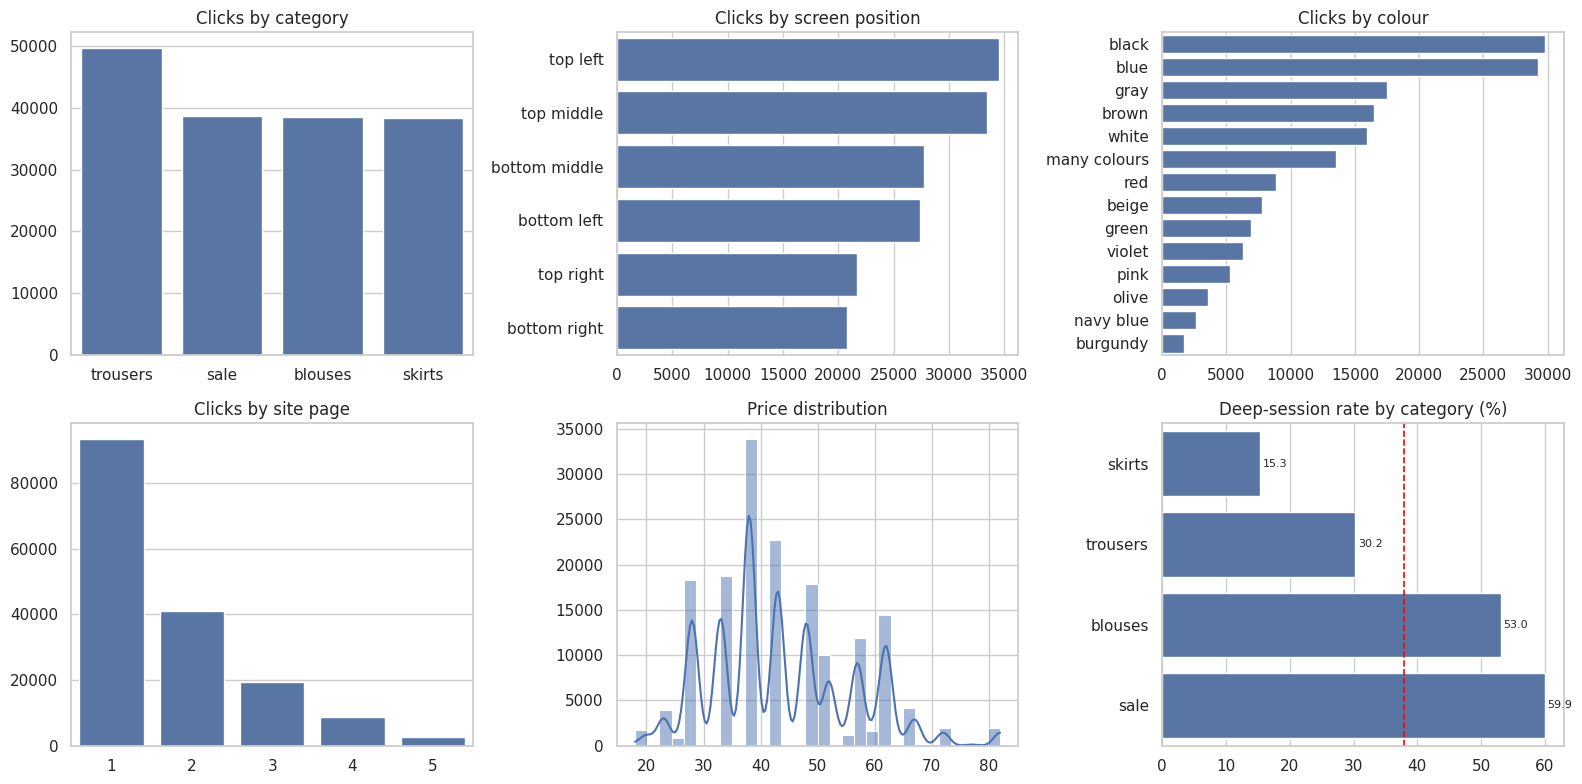

                mean  median  count
main_category                      
blouses        40.29    43.0  38577
sale           36.23    38.0  38747
skirts         51.19    52.0  38408
trousers       46.71    43.0  49742


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.countplot(data=df, x="main_category",
              order=df["main_category"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Clicks by category")

sns.countplot(data=df, y="photo_location",
              order=df["photo_location"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Clicks by screen position")

sns.countplot(data=df, y="colour",
              order=df["colour"].value_counts().index, ax=axes[0, 2])
axes[0, 2].set_title("Clicks by colour")

sns.countplot(data=df, x="page_number", ax=axes[1, 0])
axes[1, 0].set_title("Clicks by site page")

sns.histplot(df["price"], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Price distribution")

rate = (sessions.groupby("dominant_category")["deep_session"]
        .apply(lambda s: (s == "deep").mean() * 100).sort_values())
sns.barplot(x=rate.values, y=rate.index, ax=axes[1, 2], orient="h")
axes[1, 2].axvline((sessions["deep_session"] == "deep").mean() * 100,
                   color="red", linestyle="--", lw=1.2)
axes[1, 2].set_title("Deep-session rate by category (%)")
for cont in axes[1, 2].containers:
    axes[1, 2].bar_label(cont, fmt="%.1f", fontsize=8, padding=2)

for ax in axes.ravel():
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print(df.groupby("main_category")["price"].agg(["mean", "median", "count"]).round(2).to_string())

### 6.1. Cecking whether `price` can actually be predicted

`price` is the obvious choice for my D2 regression target, but we need to check one
thing first: does each product always cost the same?

If product A13 is always $28, then the product code doesn't help *predict* price,
it just tells you the answer directly, like looking it up in a price list. A model
using it would score almost perfectly while learning nothing. The check below counts
how many different prices each product actually has.

In [ ]:
g = df.groupby("clothing_model")["price"].agg(["nunique", "std"]).fillna(0)
print(f"Products:                        {len(g)}")
print(f"Products with exactly one price: {(g['nunique'] == 1).sum()} "
      f"({100 * (g['nunique'] == 1).mean():.1f}%)")
print(f"Mean within-product price std:   {g['std'].mean():.4f}")
print(f"Overall price std:               {df['price'].std():.4f}")

Products:                        217
Products with exactly one price: 217 (100.0%)
Mean within-product price std:   0.0000
Overall price std:               12.5481


**Every one of the 217 products has exactly one price**, zero within-product
variance. Not a strong correlation — an identity. `clothing_model` is a 217-row
lookup table for price stored in a different column.

**Decision for D2: exclude `clothing_model`**, and also `price_above_avg`, which is
derived arithmetically from `price`.

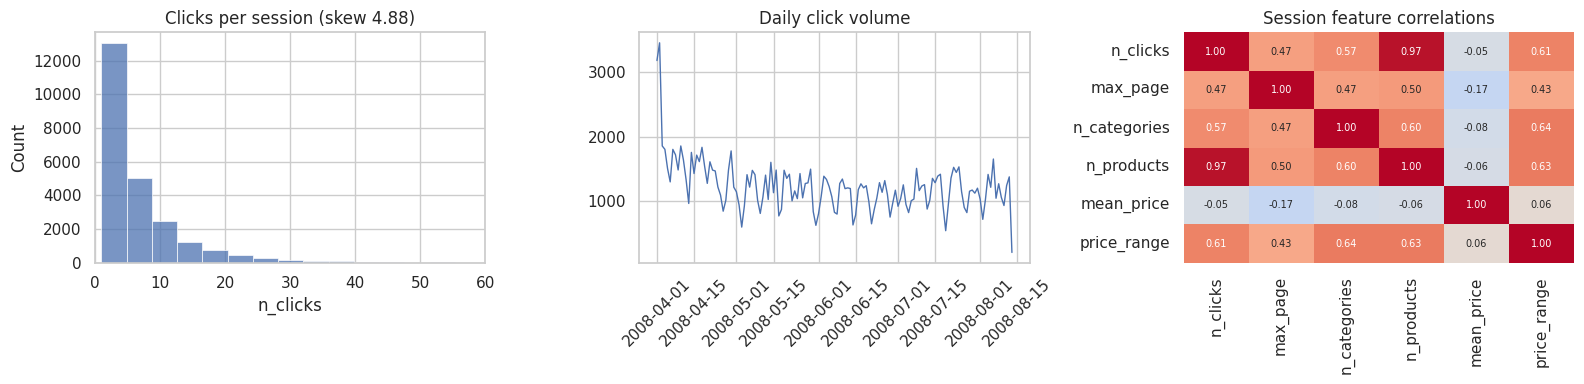

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(sessions["n_clicks"], bins=50, ax=axes[0])
axes[0].set_xlim(0, 60)
axes[0].set_title(f"Clicks per session (skew {sessions['n_clicks'].skew():.2f})")

daily = df.groupby("date").size()
axes[1].plot(daily.index, daily.values, lw=1)
axes[1].set_title("Daily click volume")
axes[1].tick_params(axis="x", rotation=45)

sns.heatmap(sessions[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[2], cbar=False, annot_kws={"size": 7})
axes[2].set_title("Session feature correlations")

plt.tight_layout(); plt.show()

## 7. Insights and Implications

**1. Six categoricals stored as integers** was the most serious data quality issue —
it would have corrupted both regression and distance-based methods silently, with no
error message.

**2. The dataset had missing values despite documentation to the contrary** (country
code 12, 210 records). No programmatic check would have found them.

**3. Unit of analysis was the key preparation decision** — 165,474 clicks collapse
to 24,026 sessions.

**4. Traffic is 81% domestic (Poland)**, so international findings rest on a small
minority of records.

**5. `price` is completely determined by `clothing_model`** — excluded from D2.

In [ ]:
df.to_csv("clickstream_clean_click_level.csv", index=False)
sessions.to_csv("clickstream_clean_session_level.csv", index=False)
print(f"click-level:   {df.shape[0]:,} x {df.shape[1]}")
print(f"session-level: {sessions.shape[0]:,} x {sessions.shape[1]}")

click-level:   165,474 x 18
session-level: 24,026 x 17


---
# Part 2 — Regression Modeling and Performance Evaluation
### (Deliverable 2)


## 1. The question

Deliverable 1 planned to predict `price`. On reflection that is not a useful
question: the store already knows what it charges, so a model that recovers its own
price list has no value to anyone.

The more useful question runs the other way round:

**Which products attract customer attention, and does price play a part?**

This is something the retailer genuinely cannot look up. It matters for
merchandising — if cheaper products drew more interest, that would argue for
promoting the sale range; if expensive ones did, it would suggest the opposite.

**Target:** the number of clicks a product received (its attention).
**Features:** price, category, colour, screen position, photo style, page.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

clicks = pd.read_csv("clickstream_clean_click_level.csv")
print(f"Loaded {clicks.shape[0]:,} click records")

Loaded 165,474 click records


## 2. Why the original target had to be abandoned

Deliverable 1 found that all 217 products have one fixed price, and excluded
`clothing_model` accordingly. But checking further shows **every** product attribute
is fixed per product (its colour, its screen position, its photo style, its page).

So the 165,474 click records contain only **217 distinct feature combinations**, one
per product, repeated thousands of times.

That breaks a normal train/test split. Clicks on the same product land in both sets,
so the model sees product A13 at $28 during training and is then asked to price A13
at test time. It is recalling, not predicting.

In [ ]:
product_features = ["main_category", "colour", "photo_location",
                    "model_photography", "page_number"]

print("Distinct values within each product (217 products):\n")
for col in product_features:
    n = clicks.groupby("clothing_model")[col].nunique()
    print(f"  {col:<20} products with only one value: {(n == 1).sum():>3} / {len(n)}")

n_combos = clicks[product_features].drop_duplicates().shape[0]
print(f"\nDistinct feature combinations across 165,474 clicks: {n_combos}")

Distinct values within each product (217 products):

  main_category        products with only one value: 216 / 217
  colour               products with only one value: 217 / 217
  photo_location       products with only one value: 217 / 217
  model_photography    products with only one value: 217 / 217
  page_number          products with only one value: 217 / 217

Distinct feature combinations across 165,474 clicks: 200


## 3. Building the product-level dataset

### Why work at product level?

Each row in this data is a click, not a product. Since my question is about which
*products* get attention, I need one row per product.

There's also no choice about it. Every product attribute — colour, position, photo
style, page, category — never changes for that product. So all 165,474 clicks only
contain 217 different combinations. Modelling at click level would just feed the
same 217 rows to the model thousands of times, which fakes a big sample without
adding any real information.

Grouping by product fixes this, and the click counts become my target: how much
attention each product got.

In [ ]:
products = clicks.groupby("clothing_model").agg(
    price=("price", "first"),
    main_category=("main_category", "first"),
    colour=("colour", "first"),
    photo_location=("photo_location", "first"),
    model_photography=("model_photography", "first"),
    page_number=("page_number", "first"),
    n_clicks=("price", "size"),          # attention: total clicks received
    n_sessions=("session_id", "nunique") # reach: distinct visitors
).reset_index()

print(f"Product catalogue: {products.shape[0]} products x {products.shape[1]} columns\n")
print(products["n_clicks"].describe().round(1).to_string())
products.head()

Product catalogue: 217 products x 9 columns

count     217.0
mean      762.6
std       614.3
min         1.0
25%       356.0
50%       590.0
75%       949.0
max      3579.0


,clothing_model,price,main_category,colour,photo_location,model_photography,page_number,n_clicks,n_sessions
0,A1,28,trousers,navy blue,top left,en face,1,2265,2104
1,A10,38,trousers,blue,bottom left,en face,1,2280,1808
2,A11,62,trousers,blue,bottom left,en face,1,2789,2454
3,A12,38,trousers,black,bottom left,en face,1,2010,1644
4,A13,28,trousers,beige,bottom middle,en face,1,1577,1428


### Feature engineering

We added four features to the raw product attributes:

- **`price_band`** — price quartile (budget > premium). Lets the model capture the
  non-linear price effect that a single numeric term would miss.
- **`is_sale_item`** — whether the category is "sale". Sale items may behave
  differently from regular stock.
- **`is_top_row`** — whether the photo sits in the top row. Tests if vertical
  position matters on its own, separately from the six-way position.
- **`clicks_per_session`** — `n_clicks / n_sessions`. Measures repeat viewing: how
  often the same visitor returns to an item.

`clicks_per_session` is **not** used as a predictor. It's calculated from the target,
so including it would leak. we kept it for interpretation only.

In [ ]:
products["price_band"] = pd.qcut(products["price"], 4,
                                 labels=["budget", "mid-low", "mid-high", "premium"])
products["is_sale_item"] = (products["main_category"] == "sale").astype(int)
products["is_top_row"] = products["photo_location"].str.startswith("top").astype(int)
products["clicks_per_session"] = products["n_clicks"] / products["n_sessions"]

TARGET = "n_clicks"
CAT_FEATURES = ["main_category", "colour", "photo_location",
                "model_photography", "price_band"]
NUM_FEATURES = ["price", "page_number", "is_sale_item", "is_top_row"]

X = products[CAT_FEATURES + NUM_FEATURES]
y = products[TARGET]

n_encoded = sum(products[c].nunique() for c in CAT_FEATURES) + len(NUM_FEATURES)
print(f"Samples: {len(X)}   Features after encoding: ~{n_encoded}")
print(f"Rows per feature: {len(X) / n_encoded:.1f}")
print(f"\nTarget '{TARGET}': mean {y.mean():.0f}, std {y.std():.0f}, "
      f"range {y.min()} to {y.max()}")

Samples: 217   Features after encoding: ~34
Rows per feature: 6.4

Target 'n_clicks': mean 763, std 614, range 1 to 3579


Roughly 7 rows per feature is a small ratio. With 217 observations and about 28
encoded features, an unregularised model has enough freedom to fit noise. This makes
Ridge and Lasso genuinely relevant here

## 4. Does price relate to attention?

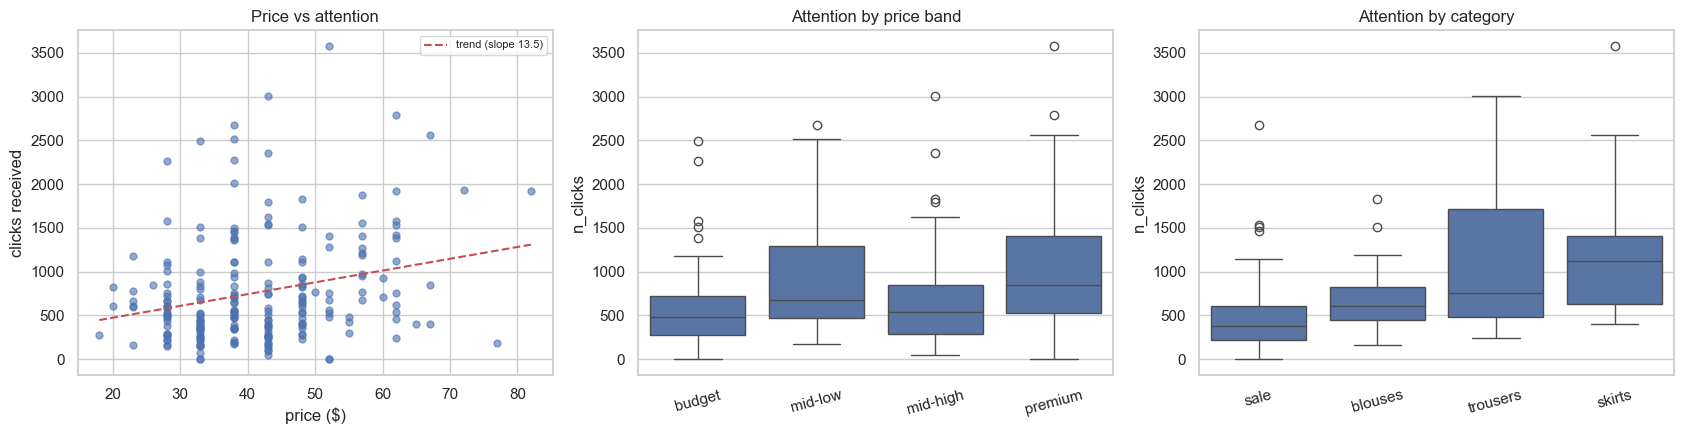

Pearson  price vs clicks: 0.2562
Spearman price vs clicks: 0.2322

            size    mean  median
price_band                      
budget        76   573.0   482.0
mid-low       38   892.0   673.0
mid-high      58   700.0   534.0
premium       45  1053.0   843.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].scatter(products["price"], products["n_clicks"], alpha=0.6, s=25)
m, b = np.polyfit(products["price"], products["n_clicks"], 1)
xs = np.linspace(products["price"].min(), products["price"].max(), 50)
axes[0].plot(xs, m * xs + b, "r--", lw=1.5, label=f"trend (slope {m:.1f})")
axes[0].set_xlabel("price ($)"); axes[0].set_ylabel("clicks received")
axes[0].set_title("Price vs attention")
axes[0].legend(fontsize=8)

sns.boxplot(data=products, x="price_band", y="n_clicks", ax=axes[1])
axes[1].set_title("Attention by price band")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=15)

sns.boxplot(data=products, x="main_category", y="n_clicks", ax=axes[2],
            order=products.groupby("main_category")["n_clicks"].median()
                          .sort_values().index)
axes[2].set_title("Attention by category")
axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

print("Pearson  price vs clicks:", round(products["price"].corr(products["n_clicks"]), 4))
print("Spearman price vs clicks:",
      round(products["price"].corr(products["n_clicks"], method="spearman"), 4))
print()
print(products.groupby("price_band", observed=True)["n_clicks"]
      .agg(["size", "mean", "median"]).round(0).to_string())

**Higher-priced products receive more attention, not less**, a positive correlation
of about 0.26. That is the opposite of the intuitive expectation that shoppers
like to cheaper items.

The price-band table also shows the effect is **not monotonic**: attention rises from
budget to mid-low, dips at mid-high, then peaks at premium. A straight line cannot
capture that shape, which is why `price_band` was engineered and why a tree-based
model is included.

## 5. Models

Four models, identical preprocessing (one-hot for categories, standardisation for
numerics) so differences come from the model rather than the data prep.

| Model | Purpose |
|---|---|
| **Linear Regression** | Baseline with no constraint |
| **Ridge** | Shrinks coefficients toward zero |
| **Lasso** | Shrinks and eliminates weak features entirely |
| **Random Forest (depth-limited)** | Captures the non-linear price effect |

In [ ]:
def make_pipeline(model):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("onehot", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
            ("scale", StandardScaler(), NUM_FEATURES),
        ])),
        ("model", model),
    ])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(model):
    return cross_val_score(make_pipeline(model), X, y, cv=cv, scoring="r2")

# Tune the regularisation strength rather than guessing it
alphas = [0.1, 1, 5, 10, 20, 50, 100, 200, 500]
ridge_scores = [cv_r2(Ridge(alpha=a)).mean() for a in alphas]
lasso_scores = [cv_r2(Lasso(alpha=a, max_iter=5000)).mean() for a in alphas]
depths = [2, 3, 4, 5, 8, None]
rf_scores = [cv_r2(RandomForestRegressor(n_estimators=300, max_depth=d,
                                         random_state=42, n_jobs=-1)).mean()
             for d in depths]

best_ridge = alphas[int(np.argmax(ridge_scores))]
best_lasso = alphas[int(np.argmax(lasso_scores))]
best_depth = depths[int(np.argmax(rf_scores))]

print(f"Best Ridge alpha:      {best_ridge}  (R2 = {max(ridge_scores):.4f})")
print(f"Best Lasso alpha:      {best_lasso}  (R2 = {max(lasso_scores):.4f})")
print(f"Best RF max_depth:     {best_depth}  (R2 = {max(rf_scores):.4f})")

Best Ridge alpha:      20  (R2 = 0.3157)
Best Lasso alpha:      20  (R2 = 0.3200)
Best RF max_depth:     2  (R2 = 0.4571)


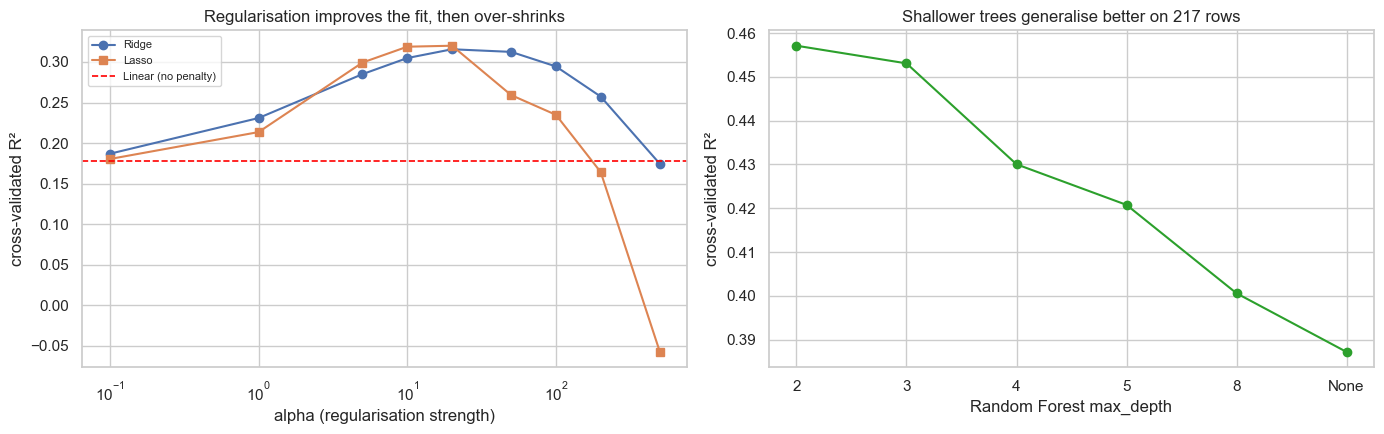

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].semilogx(alphas, ridge_scores, "o-", label="Ridge")
axes[0].semilogx(alphas, lasso_scores, "s-", label="Lasso")
axes[0].axhline(cv_r2(LinearRegression()).mean(), color="red", linestyle="--",
                lw=1.2, label="Linear (no penalty)")
axes[0].set_xlabel("alpha (regularisation strength)")
axes[0].set_ylabel("cross-validated R²")
axes[0].set_title("Regularisation improves the fit, then over-shrinks")
axes[0].legend(fontsize=8)

labels = [str(d) for d in depths]
axes[1].plot(labels, rf_scores, "o-", color="tab:green")
axes[1].set_xlabel("Random Forest max_depth")
axes[1].set_ylabel("cross-validated R²")
axes[1].set_title("Shallower trees generalise better on 217 rows")

plt.tight_layout(); plt.show()

Both curves show the same thing from different directions: **constraining the model
helps.** Ridge and Lasso peak at moderate penalty and then decline as the penalty
crushes real signal. The Random Forest performs best when its trees are kept shallow.

With only 217 observations, the binding constraint is the data, not the model.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    f"Ridge (alpha={best_ridge})": Ridge(alpha=best_ridge),
    f"Lasso (alpha={best_lasso})": Lasso(alpha=best_lasso, max_iter=5000),
    f"Random Forest (depth={best_depth})": RandomForestRegressor(
        n_estimators=300, max_depth=best_depth, random_state=42, n_jobs=-1),
}

rows = []
for name, model in models.items():
    r2 = cv_r2(model)
    rmse = -cross_val_score(make_pipeline(model), X, y, cv=cv,
                            scoring="neg_root_mean_squared_error")
    mse = rmse ** 2
    rows.append({"Model": name, "CV R2": r2.mean(), "R2 std": r2.std(),
                 "CV MSE": mse.mean(), "CV RMSE": rmse.mean()})
    print(f"{name:<30} R2 per fold: {np.round(r2, 3)}")

results = pd.DataFrame(rows).set_index("Model").round(4)
print()
results

Linear Regression              R2 per fold: [ 0.341  0.118  0.359  0.356 -0.286]
Ridge (alpha=20)               R2 per fold: [0.322 0.295 0.384 0.491 0.087]
Lasso (alpha=20)               R2 per fold: [0.314 0.326 0.346 0.461 0.154]
Random Forest (depth=2)        R2 per fold: [0.333 0.454 0.524 0.572 0.402]



,CV R2,R2 std,CV MSE,CV RMSE
Model,,,,
Linear Regression,0.1773,0.2490,275692.7182,515.7351
Ridge (alpha=20),0.3157,0.1330,238560.3801,477.1335
Lasso (alpha=20),0.3200,0.0984,242247.4804,478.9623
Random Forest (depth=2),0.4571,0.0851,189352.5080,425.7796


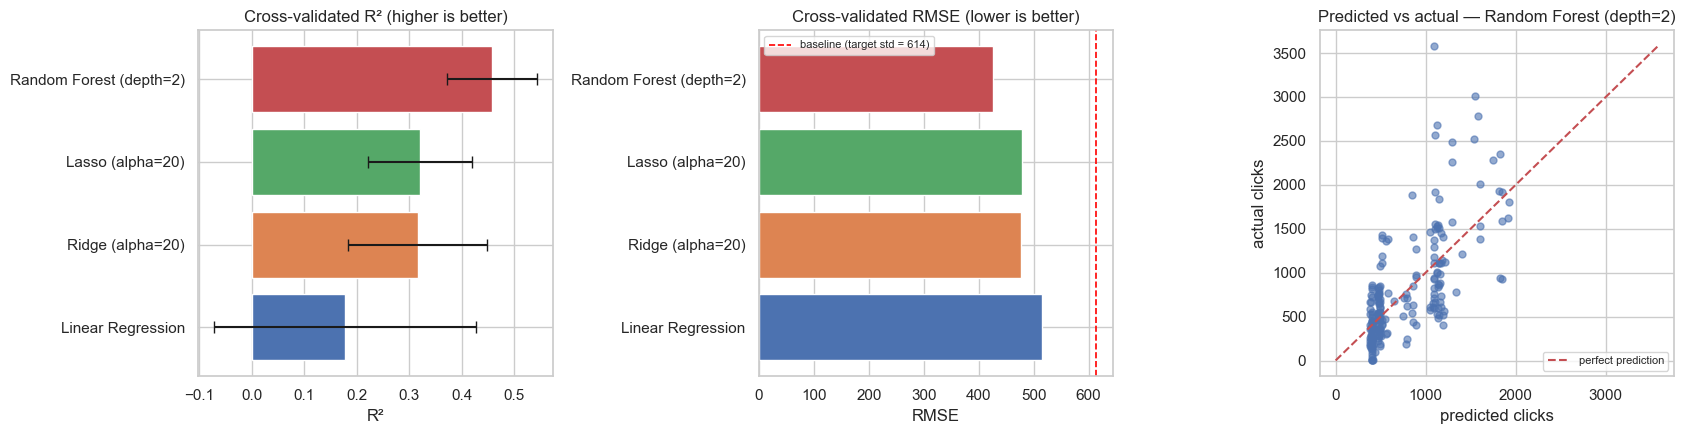

Best model: Random Forest (depth=2)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
palette = sns.color_palette("deep", len(results))

axes[0].barh(results.index, results["CV R2"], xerr=results["R2 std"],
             capsize=4, color=palette)
axes[0].set_title("Cross-validated R² (higher is better)")
axes[0].set_xlabel("R²")

axes[1].barh(results.index, results["CV RMSE"], color=palette)
axes[1].axvline(y.std(), color="red", linestyle="--", lw=1.2,
                label=f"baseline (target std = {y.std():.0f})")
axes[1].set_title("Cross-validated RMSE (lower is better)")
axes[1].set_xlabel("RMSE"); axes[1].legend(fontsize=8)

best_name = results["CV R2"].idxmax()
best_model = make_pipeline(models[best_name]).fit(X, y)
pred = cross_val_predict_vals = None
from sklearn.model_selection import cross_val_predict
pred = cross_val_predict(make_pipeline(models[best_name]), X, y, cv=cv)

axes[2].scatter(pred, y, alpha=0.6, s=25)
lims = [y.min(), y.max()]
axes[2].plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
axes[2].set_xlabel("predicted clicks"); axes[2].set_ylabel("actual clicks")
axes[2].set_title(f"Predicted vs actual — {best_name}")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"Best model: {best_name}")

## 6. What actually drives attention?

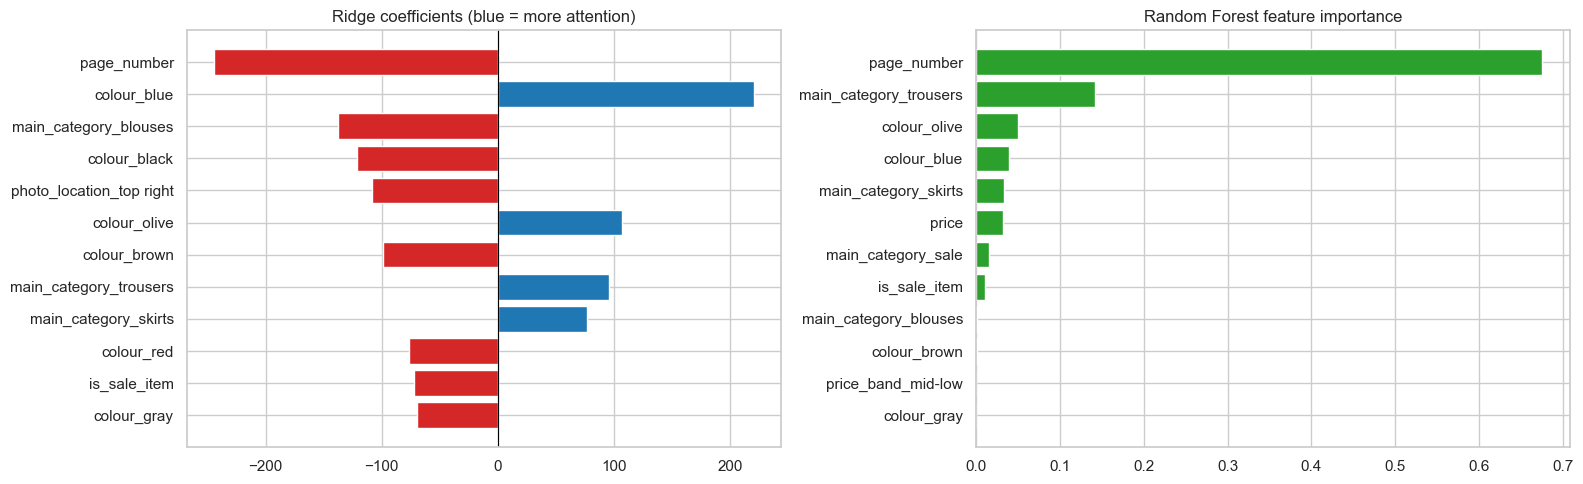

Lasso eliminated 27 of 34 features entirely.


In [ ]:
# Linear coefficients: direction and size of each effect
lin = make_pipeline(Ridge(alpha=best_ridge)).fit(X, y)
names = [n.split("__")[-1] for n in lin.named_steps["prep"].get_feature_names_out()]
coefs = pd.Series(lin.named_steps["model"].coef_, index=names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)[::-1]

# Random Forest importances: which features matter, regardless of direction
rf = make_pipeline(models[f"Random Forest (depth={best_depth})"]).fit(X, y)
imp = pd.Series(rf.named_steps["model"].feature_importances_,
                index=names).sort_values(ascending=False).head(12)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top.index, top.values,
             color=["tab:red" if v < 0 else "tab:blue" for v in top.values])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Ridge coefficients (blue = more attention)")

axes[1].barh(imp.index, imp.values, color="tab:green")
axes[1].set_title("Random Forest feature importance")

plt.tight_layout(); plt.show()

n_zero = (make_pipeline(Lasso(alpha=best_lasso, max_iter=5000))
          .fit(X, y).named_steps["model"].coef_ == 0).sum()
print(f"Lasso eliminated {n_zero} of {len(names)} features entirely.")

## 7. Results and Discussion

### Which model performed best?

The **depth-limited Random Forest** wins, and the ordering of the four models tells a
consistent story:

- Plain **Linear Regression** performs worst and has the widest fold-to-fold spread, 
  the signature of overfitting on 217 rows.
- **Ridge** and **Lasso** both improve substantially on it. With roughly 8 rows per
  feature, the unconstrained model was fitting noise, and shrinking the coefficients
  fixed that.
- **Random Forest** does best of all, but only when kept shallow. Unrestricted, it
  performs worse than Ridge.

Every step of that ordering points the same way: with this little data, constraining
the model matters more than making it flexible.

### Does price attract attention?

**Yes — and in the opposite direction to intuition.** Higher-priced products receive
*more* clicks, with a positive correlation of about 0.26.

### Other Features

**Category matters more than price.** Skirts and trousers attract roughly twice the
attention of sale items. The sale category is the least-viewed of the four, which
sits oddly beside the finding that premium prices draw interest — both point toward
discounting not being the main driver of engagement here.

**Screen position has a measurable effect** but a smaller one than either category or
price, consistent with the Deliverable 1 finding that top-left leads and bottom-right
trails.

**Colour contributes little.** Most colour coefficients are small and Lasso
eliminates several entirely.

### Limitations

**217 observations is a small sample.** The cross-validation standard deviations are
large (±0.13 to ±0.17), so the gap between Ridge and Random Forest is real but not
precisely measured. Reported to two decimal places, these numbers would imply more
certainty than exists.

**Attention is not the same as sales.** This dataset records browsing only. A product
that attracts clicks but no purchases would look identical here to one that sells
well, so none of these findings should be read as a revenue recommendation.

**Correlation, not causation.** Premium products may attract attention because they
are premium, or because they are also the newest, best-photographed, or most
prominently placed. The data cannot separate these.

### Practical implication

If the goal is engagement, the evidence does not support leading with discounts. The
sale category draws the least attention of the four, and premium pricing draws the
most. Prominent placement of higher-priced skirts and trousers is better supported by
this data than promoting the sale range, subject to the caveat that engagement is
not revenue.

In [ ]:
results.to_csv("d2_model_comparison.csv")
products.to_csv("d2_product_level.csv", index=False)

print("Final comparison (sorted by cross-validated R²):\n")
results.sort_values("CV R2", ascending=False).round(4)

Final comparison (sorted by cross-validated R²):



,CV R2,R2 std,CV MSE,CV RMSE
Model,,,,
Random Forest (depth=2),0.4571,0.0851,189352.5080,425.7796
Lasso (alpha=20),0.3200,0.0984,242247.4804,478.9623
Ridge (alpha=20),0.3157,0.1330,238560.3801,477.1335
Linear Regression,0.1773,0.2490,275692.7182,515.7351


---
# Part 3 — Classification, Clustering, and Pattern Mining
### (Deliverable 3)

## 1. Overview

Deliverable 2 asked which *products* attract attention. This deliverable moves to
*visitors* and asks three questions:

- **Part A — Classification.** Can We tell from a visitor's first two clicks whether
  they'll browse deeply? *(Decision Tree, k-NN, Naive Bayes)*
- **Part B — Clustering.** What types of shopping session exist? *(K-Means)*
- **Part C — Pattern mining.** Which products get browsed together? *(Apriori)*

Part A is framed around the **first two clicks** deliberately. Predicting engagement
from a whole session is circular — a long session is deep almost by definition. Using
only the opening clicks makes it a real prediction problem, and a practically useful
one: a retailer could act on it while the visitor is still on the site.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             accuracy_score, f1_score, classification_report, silhouette_score)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

clicks = pd.read_csv("clickstream_clean_click_level.csv").sort_values(["session_id", "click_order"])
sessions = pd.read_csv("clickstream_clean_session_level.csv")

print(f"Clicks:   {clicks.shape[0]:,}")
print(f"Sessions: {sessions.shape[0]:,}")

Clicks:   165,474
Sessions: 24,026


# Part A — Classification

## 2. Building the prediction task

**Target:** did the session reach page 3 or deeper? (`deep` vs `shallow`)

**Features:** taken from the **first two clicks only**, what the visitor landed on,
its price, its colour, where the photo sat, plus context like country and weekday.

Sessions with only one click are excluded, since there is no second click to observe.
That leaves 18,984 of 24,026 sessions.

In [ ]:
# Features from the opening two clicks
early = clicks[clicks["click_order"] <= 2]

features = early.groupby("session_id").agg(
    first_category=("main_category", "first"),
    first_colour=("colour", "first"),
    first_location=("photo_location", "first"),
    first_photo=("model_photography", "first"),
    first_price=("price", "first"),
    mean_early_price=("price", "mean"),
    n_early_categories=("main_category", "nunique"),
    country_group=("country_group", "first"),
    weekday=("weekday", "first"),
    month=("month", "first"),
).reset_index()

# Target from the whole session
depth = clicks.groupby("session_id")["page_number"].max().rename("max_page").reset_index()
sizes = clicks.groupby("session_id").size()

data = features.merge(depth, on="session_id")
data = data[data["session_id"].isin(sizes[sizes >= 2].index)].copy()
data["deep"] = (data["max_page"] >= 3).astype(int)

print(f"Sessions usable: {len(data):,} of {sizes.shape[0]:,}")
print(f"\nClass balance:")
print(data["deep"].value_counts().rename({0: "shallow", 1: "deep"}).to_string())
print(f"\nDeep rate: {100 * data['deep'].mean():.1f}%")
print(f"Majority-class baseline accuracy: {max(data['deep'].mean(), 1 - data['deep'].mean()):.4f}")

Sessions usable: 18,984 of 24,026

Class balance:
deep
shallow    10320
deep        8664

Deep rate: 45.6%
Majority-class baseline accuracy: 0.5436


In [ ]:
CAT = ["first_category", "first_colour", "first_location",
       "first_photo", "country_group", "weekday"]
NUM = ["first_price", "mean_early_price", "n_early_categories", "month"]

X = data[CAT + NUM]
y = data["deep"]

def build(model):
    """Identical preprocessing for every classifier so comparisons are fair."""
    return Pipeline([
        ("prep", ColumnTransformer([
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
            ("scale", StandardScaler(), NUM),
        ])),
        ("model", model),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Stratified, so both keep a {100 * y_train.mean():.1f}% deep rate.")

Train: 15,187   Test: 3,797
Stratified, so both keep a 45.6% deep rate.


## 3. Three classifiers

`stratify=y` on the split, and `StratifiedKFold` for cross-validation, both keep the
class proportions constant. Without this, a fold could end up with an unrepresentative
mix and the scores would wobble for reasons unrelated to the models.

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
pd.set_option("display.notebook_repr_html", False)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Naive Bayes": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in models.items():
    pipe = build(model)
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1 = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    roc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    rows.append({"Model": name, "Accuracy": acc.mean(), "F1": f1.mean(),
                 "ROC-AUC": roc.mean(), "Acc std": acc.std()})
    print(f"{name:<16} accuracy={acc.mean():.4f}  F1={f1.mean():.4f}  AUC={roc.mean():.4f}")

baseline_results = pd.DataFrame(rows).set_index("Model").round(4)
print()
baseline_results

Decision Tree    accuracy=0.6401  F1=0.5449  AUC=0.6743
k-NN (k=25)      accuracy=0.6286  F1=0.5387  AUC=0.6706
Naive Bayes      accuracy=0.5959  F1=0.4790  AUC=0.6288



               Accuracy      F1  ROC-AUC  Acc std
Model                                            
Decision Tree    0.6401  0.5449   0.6743   0.0058
k-NN (k=25)      0.6286  0.5387   0.6706   0.0062
Naive Bayes      0.5959  0.4790   0.6288   0.0049

## 4. Hyperparameter tuning

The Decision Tree is tuned with `GridSearchCV`, which fits every combination of the
listed parameters under cross-validation and keeps the best.

**Why these parameters:**

- **`max_depth`** — the main control on overfitting. A deep tree can memorise
  individual sessions; a shallow one may miss real structure.
- **`min_samples_leaf`** — forces each leaf to cover a minimum number of sessions, so
  the tree cannot build rules from a handful of examples.
- **`criterion`** — gini and entropy measure split quality differently; usually
  similar in practice, included to confirm rather than assume.

**Scoring on F1 rather than accuracy**, because F1 balances precision and recall.
With a 46/54 split, accuracy can be inflated by favouring the majority class.

In [ ]:
param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15, None],
    "model__min_samples_leaf": [1, 10, 50, 100],
    "model__criterion": ["gini", "entropy"],
}

grid = GridSearchCV(
    build(DecisionTreeClassifier(random_state=42)),
    param_grid, cv=cv, scoring="f1", n_jobs=1, verbose=0,
)
grid.fit(X_train, y_train)

print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nBest cross-validated F1: {grid.best_score_:.4f}")
print(f"Untuned Decision Tree F1: {baseline_results.loc['Decision Tree', 'F1']:.4f}")

tuned_tree = grid.best_estimator_

Best parameters:
  criterion: entropy
  max_depth: 10
  min_samples_leaf: 10

Best cross-validated F1: 0.5692
Untuned Decision Tree F1: 0.5449


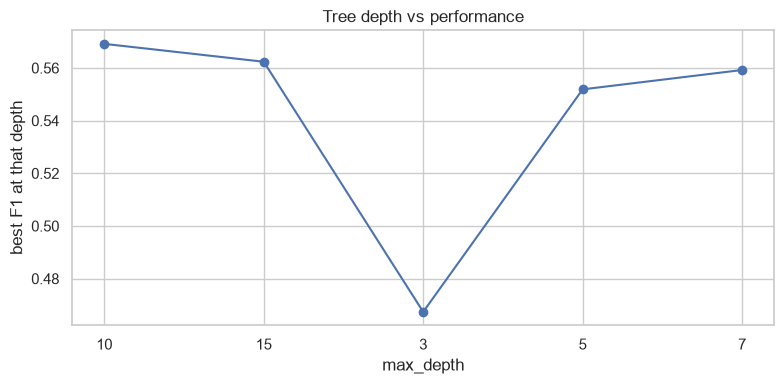

  max_depth  best_F1
0        10   0.5692
1        15   0.5624
2         3   0.4674
3         5   0.5519
4         7   0.5592

In [ ]:
# How does performance vary with tree depth?
cv_df = pd.DataFrame(grid.cv_results_)
depth_effect = (cv_df.groupby(cv_df["param_model__max_depth"].astype(str))["mean_test_score"]
                     .max().reset_index())
depth_effect.columns = ["max_depth", "best_F1"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_effect["max_depth"], depth_effect["best_F1"], "o-")
ax.set_xlabel("max_depth"); ax.set_ylabel("best F1 at that depth")
ax.set_title("Tree depth vs performance")
plt.tight_layout(); plt.show()

depth_effect.round(4)

## 5. Evaluation — confusion matrix, ROC, accuracy and F1

In [ ]:
final_models = {
    "Decision Tree (tuned)": tuned_tree,
    "k-NN (k=25)": build(KNeighborsClassifier(n_neighbors=25)).fit(X_train, y_train),
    "Naive Bayes": build(GaussianNB()).fit(X_train, y_train),
}

test_rows = []
for name, model in final_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": auc(fpr, tpr),
    })

test_results = pd.DataFrame(test_rows).set_index("Model").round(4)
print("Hold-out test set:\n")
test_results

Hold-out test set:



                       Accuracy      F1  ROC-AUC
Model                                           
Decision Tree (tuned)    0.6355  0.5667   0.6693
k-NN (k=25)              0.6268  0.5460   0.6644
Naive Bayes              0.5960  0.4977   0.6276

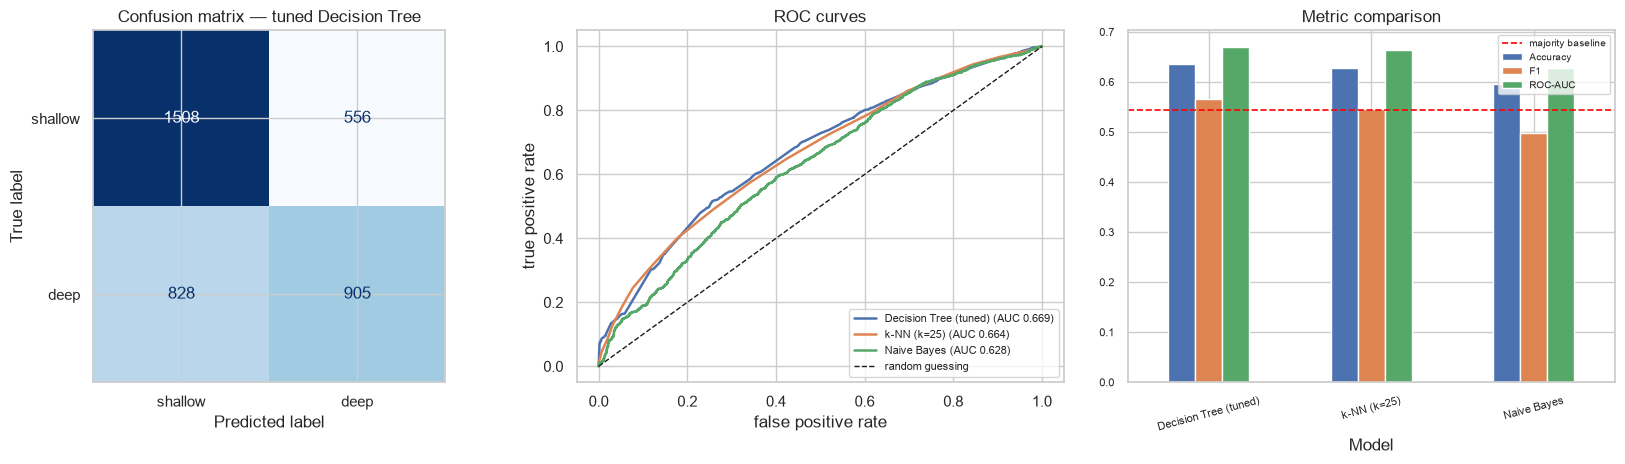

              precision    recall  f1-score   support

     shallow       0.65      0.73      0.69      2064
        deep       0.62      0.52      0.57      1733

    accuracy                           0.64      3797
   macro avg       0.63      0.63      0.63      3797
weighted avg       0.63      0.64      0.63      3797



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Confusion matrix for the tuned tree
best_pred = tuned_tree.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["shallow", "deep"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix — tuned Decision Tree")

# ROC curves for all three
for name, model in final_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, lw=1.8, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="random guessing")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curves")
axes[1].legend(fontsize=8, loc="lower right")

# Metric comparison
test_results.plot(kind="bar", ax=axes[2], rot=15)
axes[2].axhline(max(y.mean(), 1 - y.mean()), color="red", linestyle="--", lw=1.2,
                label="majority baseline")
axes[2].set_title("Metric comparison")
axes[2].legend(fontsize=7)
axes[2].tick_params(labelsize=8)

plt.tight_layout(); plt.show()

print(classification_report(y_test, best_pred, target_names=["shallow", "deep"]))

### Confusion matrix

The matrix shows where the tuned tree gets things right and wrong. The two error
types are not equally costly in practice:

- **False positives** (predicted deep, actually shallow) — a visitor gets an
  intervention they did not need. Mild cost.
- **False negatives** (predicted shallow, actually deep) — an engaged visitor is
  missed. Higher opportunity cost.

If this were deployed, the decision threshold could be lowered to catch more genuine
deep sessions at the price of more false alarms. The ROC curve shows that trade-off
across every possible threshold, which is why it is more informative here than a
single accuracy number.

## 6. What the tree learned

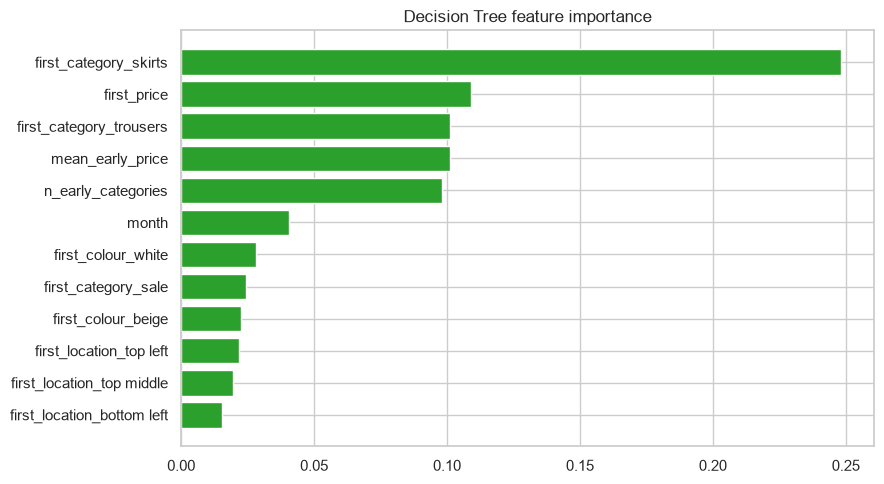

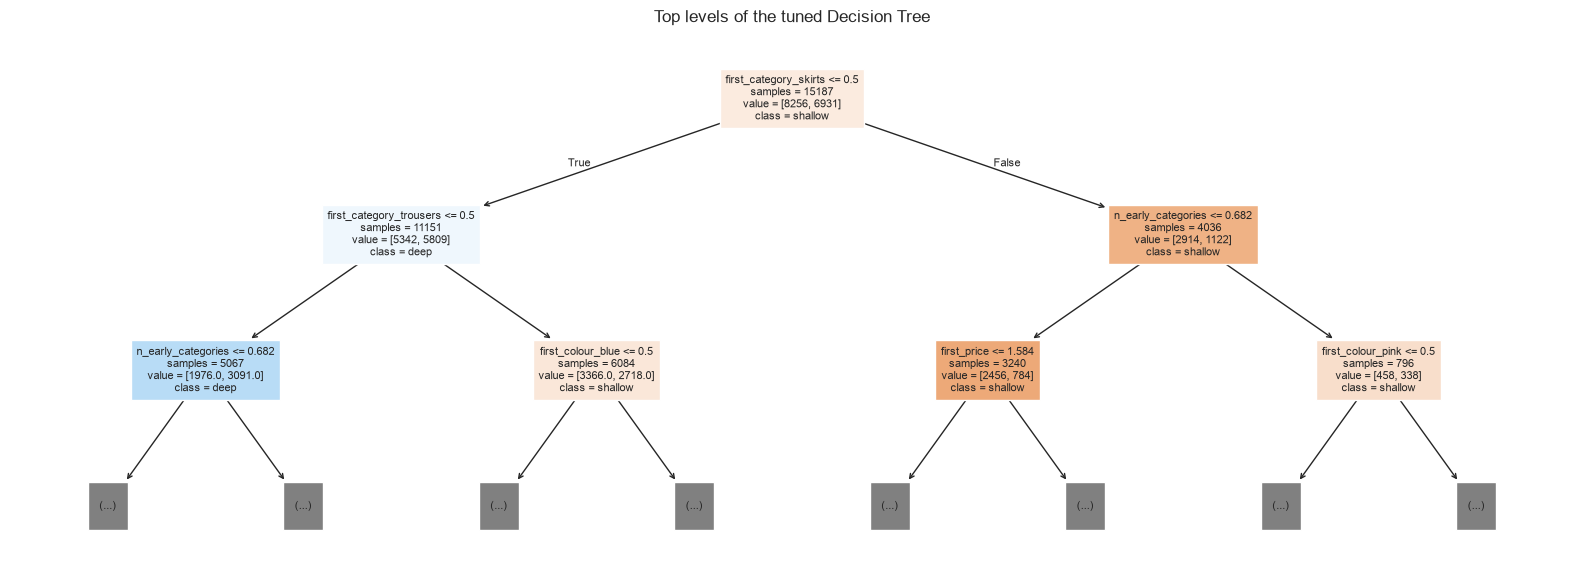

In [ ]:
tree = tuned_tree.named_steps["model"]
names = [n.split("__")[-1] for n in tuned_tree.named_steps["prep"].get_feature_names_out()]

imp = pd.Series(tree.feature_importances_, index=names)
imp = imp[imp > 0].sort_values(ascending=False).head(12)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index, imp.values, color="tab:green")
ax.set_title("Decision Tree feature importance")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree, max_depth=2, feature_names=names, class_names=["shallow", "deep"],
          filled=True, fontsize=8, ax=ax, impurity=False)
ax.set_title("Top levels of the tuned Decision Tree")
plt.tight_layout(); plt.show()

# Part B — Clustering

## 7. Finding session types

K-Means groups sessions by behaviour. Features are **standardised first** because
K-Means uses Euclidean distance: without scaling, `mean_price` (range ~18–82) would
dominate `n_categories` (range 1–4) purely because of its units.

`log_n_clicks` is used instead of raw click counts, for the reason established in
Deliverable 1, the raw distribution is heavily right-skewed, and a handful of
195-click sessions would otherwise pull the cluster centres toward themselves.

k=2  inertia=   81852  silhouette=0.3601
k=3  inertia=   66870  silhouette=0.2638
k=4  inertia=   54315  silhouette=0.2721
k=5  inertia=   47708  silhouette=0.2688
k=6  inertia=   43097  silhouette=0.2646
k=7  inertia=   40047  silhouette=0.2537
k=8  inertia=   37626  silhouette=0.2447


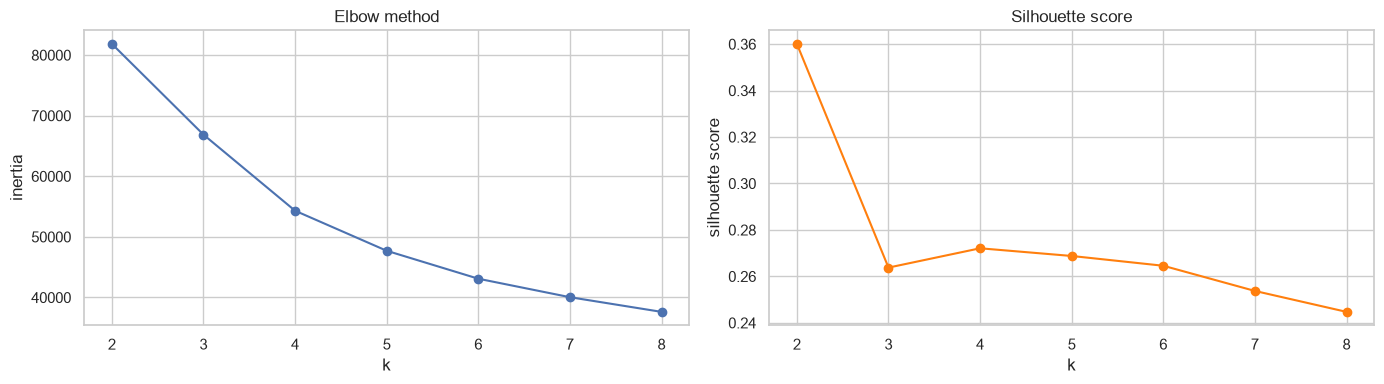

In [ ]:
CLUSTER_FEATURES = ["log_n_clicks", "max_page", "n_categories",
                    "n_colours", "mean_price", "price_range"]

X_cluster = StandardScaler().fit_transform(sessions[CLUSTER_FEATURES])

# Silhouette on a sample - it is O(n^2) and would be slow on 24,026 rows
sample = np.random.default_rng(42).choice(len(X_cluster), 5000, replace=False)

inertias, silhouettes, ks = [], [], range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster[sample], km.labels_[sample]))
    print(f"k={k}  inertia={km.inertia_:>8.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")
axes[1].plot(list(ks), silhouettes, "o-", color="tab:orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

### Choosing k — where the metric and the use case disagree

The silhouette score is highest at **k=2**. But inspecting that solution shows it
splits sessions only into "short" and "long", a distinction already captured by
`n_clicks` alone, so clustering adds nothing.

**k=4 is used instead.** Its silhouette is lower, but it separates sessions on *two*
dimensions — engagement level *and* price level, producing groups that are
distinguishable in ways a single existing column does not already capture.

This is a judgement call and is recorded as one. The silhouette score measures how
cleanly separated clusters are, not how useful they are, and those are not the same
question. Both solutions are profiled below so the trade-off is visible.

In [ ]:
for k in [2, 4]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster)
    sessions[f"cluster_k{k}"] = labels
    profile = sessions.groupby(f"cluster_k{k}").agg(
        n_sessions=("n_clicks", "size"),
        clicks=("n_clicks", "mean"),
        max_page=("max_page", "mean"),
        categories=("n_categories", "mean"),
        colours=("n_colours", "mean"),
        price=("mean_price", "mean"),
        price_range=("price_range", "mean"),
    ).round(1)
    print(f"--- k={k} ---")
    print(profile.to_string())
    print()

sessions["cluster"] = sessions["cluster_k4"]

--- k=2 ---
            n_sessions  clicks  max_page  categories  colours  price  price_range
cluster_k2                                                                       
0                14407     2.6       1.6         1.3      1.9   44.9         11.6
1                 9619    13.3       3.2         2.7      6.0   43.6         35.9

--- k=4 ---
            n_sessions  clicks  max_page  categories  colours  price  price_range
cluster_k4                                                                       
0                 8376     6.1       2.3         1.9      3.7   44.8         28.9
1                 5285    18.0       3.7         3.1      7.4   43.0         39.3
2                 5754     1.8       1.6         1.2      1.5   36.2          4.4
3                 4611     1.9       1.4         1.1      1.5   55.4          8.2



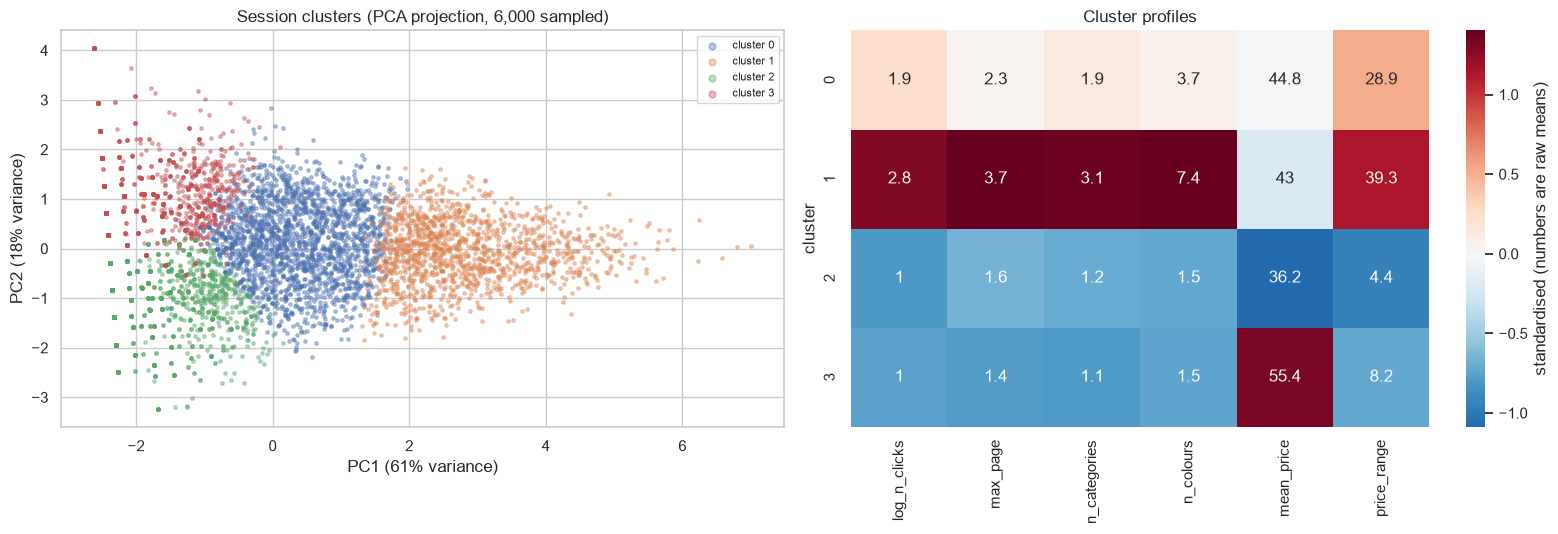

In [ ]:
# Visualise the 4 clusters: PCA projection + behavioural profile
pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sub = np.random.default_rng(0).choice(len(coords), 6000, replace=False)
for cl in sorted(sessions["cluster"].unique()):
    m = sessions["cluster"].values[sub] == cl
    axes[0].scatter(coords[sub][m, 0], coords[sub][m, 1], s=6, alpha=0.4, label=f"cluster {cl}")
axes[0].set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.0f}% variance)")
axes[0].set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.0f}% variance)")
axes[0].set_title("Session clusters (PCA projection, 6,000 sampled)")
axes[0].legend(fontsize=8, markerscale=2)

profile = sessions.groupby("cluster")[CLUSTER_FEATURES].mean()
normed = (profile - profile.mean()) / profile.std()
sns.heatmap(normed, annot=profile.round(1), fmt="g", cmap="RdBu_r", center=0,
            ax=axes[1], cbar_kws={"label": "standardised (numbers are raw means)"})
axes[1].set_title("Cluster profiles")
axes[1].set_ylabel("cluster")

plt.tight_layout(); plt.show()

### The four session types

Reading the profile heatmap, the clusters separate into recognisable shopper
behaviours:

- **Cluster 2 — Budget bouncers** (~5,750 sessions). About 2 clicks, lowest prices
  (~$36), one category. They arrive, look at something cheap, and leave.
- **Cluster 3 — Premium bouncers** (~4,600 sessions). About 2 clicks, highest prices
  (~$55), one category. The same brief visit, but looking at expensive items.
- **Cluster 0 — Moderate browsers** (~8,400 sessions). About 6 clicks across 2
  categories at mid prices. The largest group.
- **Cluster 1 — Deep explorers** (~5,300 sessions). About 18 clicks, 3 categories, 7
  colours, and the widest price range. Highly engaged.

The most useful finding here is that the two brief-visit groups are **not the same
segment**. Both leave after roughly two clicks, but one is looking at the cheapest
items and the other at the most expensive. A retention effort treating them
identically would misread half of them, and note that a k=2 solution would have
merged exactly these two groups, which is the concrete reason k=4 was chosen.

# Part C — Association Rule Mining

## 8. Session baskets

Each session is treated as a transaction containing the attributes of everything
browsed. Association rules then reveal which attributes are viewed together.

This dataset needs no artificial discretisation for this step, sessions are already
baskets.

In [ ]:
# Build baskets from attributes that vary within a session
clicks["price_band"] = pd.qcut(clicks["price"], 4,
                               labels=["budget", "mid-low", "mid-high", "premium"])
clicks["item_category"] = "cat=" + clicks["main_category"]
clicks["item_price"] = "price=" + clicks["price_band"].astype(str)

long = pd.concat([
    clicks[["session_id", "item_category"]].rename(columns={"item_category": "item"}),
    clicks[["session_id", "item_price"]].rename(columns={"item_price": "item"}),
])
baskets = long.groupby("session_id")["item"].apply(lambda s: sorted(set(s))).tolist()

encoder = TransactionEncoder()
basket_df = pd.DataFrame(encoder.fit(baskets).transform(baskets), columns=encoder.columns_)

print(f"Transactions: {len(baskets):,}")
print(f"Distinct items: {basket_df.shape[1]}")
print(f"Mean items per session: {np.mean([len(b) for b in baskets]):.1f}")

Transactions: 24,026
Distinct items: 8
Mean items per session: 4.3


In [ ]:
frequent = apriori(basket_df, min_support=0.03, use_colnames=True, max_len=3)
rules = association_rules(frequent, metric="lift", min_threshold=1.05)
rules = rules[rules["confidence"] >= 0.4].sort_values("lift", ascending=False)

print(f"Frequent itemsets: {len(frequent)}   Rules (lift>1.05, conf>=0.4): {len(rules)}\n")

display_rules = rules.head(10).copy()
display_rules["antecedents"] = display_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
display_rules["consequents"] = display_rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
display_rules[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

Frequent itemsets: 92   Rules (lift>1.05, conf>=0.4): 274



                      antecedents                   consequents  support  \
84        cat=blouses, cat=skirts                price=mid-high    0.186   
129                   cat=blouses  price=budget, price=mid-high    0.271   
124  price=budget, price=mid-high                   cat=blouses    0.271   
53          cat=blouses, cat=sale                price=mid-high    0.162   
106  cat=trousers, price=mid-high                   cat=blouses    0.205   
111                   cat=blouses  cat=trousers, price=mid-high    0.205   
110                price=mid-high     cat=blouses, cat=trousers    0.205   
107     cat=blouses, cat=trousers                price=mid-high    0.205   
149    cat=blouses, price=premium                price=mid-high    0.228   
152                price=mid-high    cat=blouses, price=premium    0.228   

     confidence   lift  
84        0.894  1.786  
129       0.608  1.756  
124       0.784  1.756  
53        0.857  1.713  
106       0.755  1.692  
111       0.4

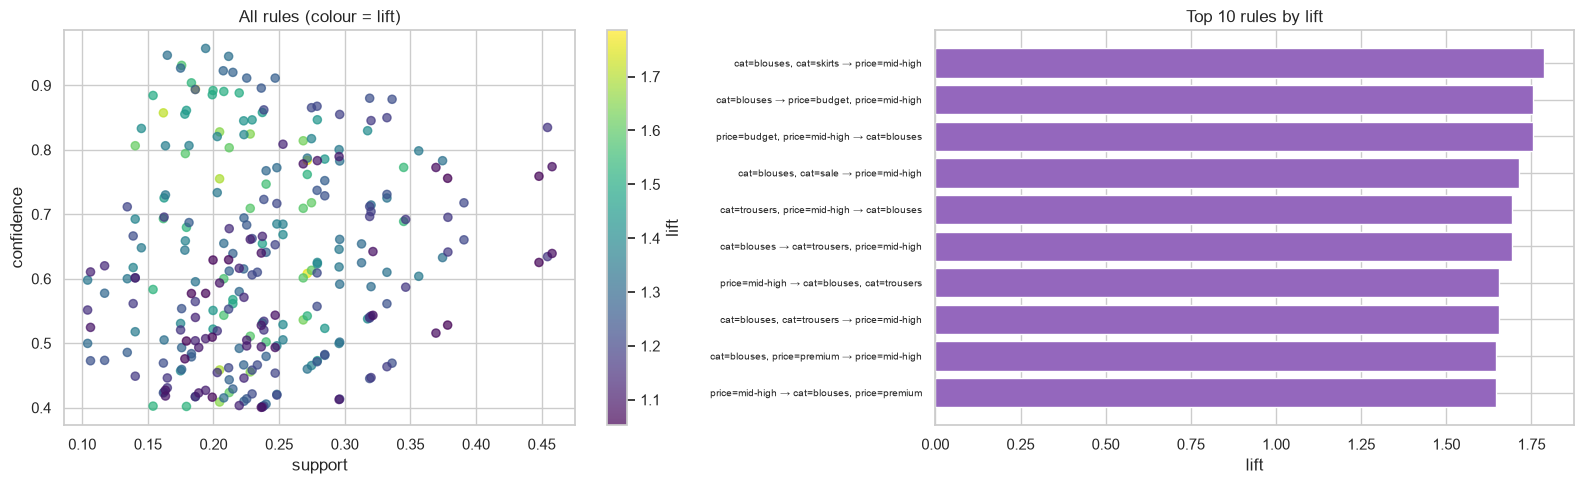

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(rules["support"], rules["confidence"],
                c=rules["lift"], cmap="viridis", s=35, alpha=0.7)
axes[0].set_xlabel("support"); axes[0].set_ylabel("confidence")
axes[0].set_title("All rules (colour = lift)")
plt.colorbar(axes[0].collections[0], ax=axes[0], label="lift")

top = rules.head(10)
labels = [f"{', '.join(sorted(a))} → {', '.join(sorted(c))}"
          for a, c in zip(top["antecedents"], top["consequents"])]
axes[1].barh(range(len(top)), top["lift"].values[::-1], color="tab:purple")
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(labels[::-1], fontsize=7)
axes[1].set_xlabel("lift")
axes[1].set_title("Top 10 rules by lift")

plt.tight_layout(); plt.show()

### What the rules say

**Lift** is the key metric: a lift of 1.8 means the combination occurs 80% more often
than it would if the two items were unrelated. Support says how common the pattern
is; confidence says how reliable it is once the antecedent appears.

Two patterns stand out:

**1. Shoppers browse across categories, not within one.** Rules linking blouses with
trousers and skirts appear repeatedly at lift around 1.65–1.79. Visitors are not
looking for "a skirt", they are assembling outfits, moving between garment types in
a single session.

**2. Shoppers mix price tiers within one session.** Budget items co-occur with
mid-high items at lift 1.76. The same visitor looks at both cheap and expensive
products, which argues against treating "budget shopper" and "premium shopper" as
fixed customer types, at least within a session.

## 9. Insights and Real-World Applications

### Classification — predicting engagement early

The tuned Decision Tree beats the majority baseline, though modestly. Two clicks is
genuinely little information, and the honest conclusion is that early behaviour
carries *some* signal about eventual engagement, not that engagement is
straightforwardly predictable.

**Practical use:** a model like this could drive a real-time decision, offering
assistance, a recommendation, or a promotion to visitors predicted to disengage. The
threshold matters more than the accuracy: since missing an engaged visitor costs more
than an unnecessary prompt, the model should be tuned toward recall rather than
overall accuracy.

**Limitation:** predicting depth is not predicting purchase. This dataset has no
sales, so a "deep" session is engaged, not necessarily valuable.

### Clustering — four session types

The most actionable result is the split between **budget bouncers** and **premium
bouncers**. Both leave after about two clicks, so a bounce-rate report would merge
them, but they are looking at opposite ends of the price range and plausibly need
different treatment, price reassurance for one, quality or delivery information for
the other.

**Deep explorers** (~5,300 sessions) are the natural audience for recommendation
features, since they already browse widely across categories and colours.

### Pattern mining — cross-category browsing

The strongest behavioural pattern is that shoppers move **between** garment
categories within a session, at lift 1.65–1.79.

**Practical use:** this argues for cross-category recommendations ("complete the
outfit") over more-of-the-same suggestions, and for merchandising that places
complementary garment types near each other rather than strictly segregating
categories.